# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan (Jaya Jaya Institut)

- Nama: Jason Clarence
- Email: jason_clarence_sab51@dicoding.com
- Id Dicoding: jason_clarence_sab51

## Business Understanding

Jaya Jaya Institut adalah institusi pendidikan tinggi yang berdiri sejak tahun 2000 dan telah mencetak banyak lulusan bereputasi baik. Namun, institusi menghadapi **tingkat dropout yang tinggi** — banyak mahasiswa tidak menyelesaikan pendidikannya. Hal ini berdampak pada reputasi, pendapatan, dan efektivitas institusi.

### Permasalahan Bisnis

1. Bagaimana karakteristik mahasiswa yang dropout vs yang lulus/bertahan?
2. Faktor apa saja yang paling berpengaruh terhadap risiko dropout seorang mahasiswa?
3. Bagaimana mendeteksi sedini mungkin mahasiswa yang berisiko dropout agar dapat diberi bimbingan khusus?
4. Bagaimana memonitor performa mahasiswa secara berkala melalui dashboard?

### Cakupan Proyek

1. Analisis data (EDA) untuk memahami faktor-faktor yang membedakan mahasiswa dropout.
2. Membangun model machine learning untuk memprediksi status akhir mahasiswa (Dropout / Enrolled / Graduate).
3. Membuat business dashboard untuk monitoring performa mahasiswa.
4. Membuat prototype sistem prediksi dropout berbasis Streamlit yang dapat dijalankan di cloud.
5. Memberikan rekomendasi action items berdasarkan temuan.

### Goals

- Model prediksi dropout dengan performa yang baik (fokus pada *recall* kelas Dropout agar tidak banyak mahasiswa berisiko yang terlewat).
- Dashboard monitoring yang menampilkan faktor-faktor penting dropout.
- Prototype prediksi yang dapat digunakan oleh tim bimbingan konseling.

## Persiapan

### Menyiapkan library yang dibutuhkan

Library yang digunakan: `pandas` & `numpy` untuk manipulasi data, `matplotlib` & `seaborn` untuk visualisasi, `scikit-learn` untuk preprocessing, modeling, dan evaluasi, serta `joblib` untuk menyimpan model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
os.makedirs('model', exist_ok=True)
print('Library berhasil dimuat.')

Library berhasil dimuat.


### Menyiapkan data yang akan digunakan

Sumber data: [Students' Performance - Dicoding Dataset](https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance) (berasal dari UCI ML Repository, Realinho et al., 2021).

Dataset berisi informasi mahasiswa yang diketahui saat pendaftaran (jalur akademik, demografi, faktor sosial-ekonomi) serta performa akademik pada akhir semester 1 dan 2. File CSV menggunakan pemisah `;`.

In [2]:
df = pd.read_csv('data/data.csv', sep=';', encoding='utf-8-sig')
# Normalisasi nama kolom: rapikan spasi/BOM, lalu samakan nama kolom target
df.columns = df.columns.str.strip()
df = df.rename(columns={'Status': 'Target'})
print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print('Kolom target   :', [c for c in df.columns if c.lower() in ('target', 'status')])
df.head()

Jumlah baris   : 4424
Jumlah kolom   : 37
Kolom target   : ['Target']


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Tahap ini bertujuan memahami struktur data, tipe tiap kolom, kualitas data (missing value, duplikat), serta distribusi target dan fitur-fitur penting.

### Struktur & Kualitas Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [4]:
print('Missing values per kolom:')
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() > 0 else 'Tidak ada missing value.')
print(f'\nBaris duplikat: {df.duplicated().sum()}')

Missing values per kolom:
Tidak ada missing value.

Baris duplikat: 0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


**Insight:** Dataset memiliki 4.424 baris dan 37 kolom (36 fitur + 1 target), tanpa missing value dan tanpa duplikat. Kolom kategorikal sudah direpresentasikan sebagai kode integer (misal `Course`, `Marital_status`), sedangkan kolom numerik meliputi nilai, jumlah SKS, dan indikator makro-ekonomi.

### Distribusi Target

          Jumlah  Persentase (%)
Target                          
Graduate    2209            49.9
Dropout     1421            32.1
Enrolled     794            17.9


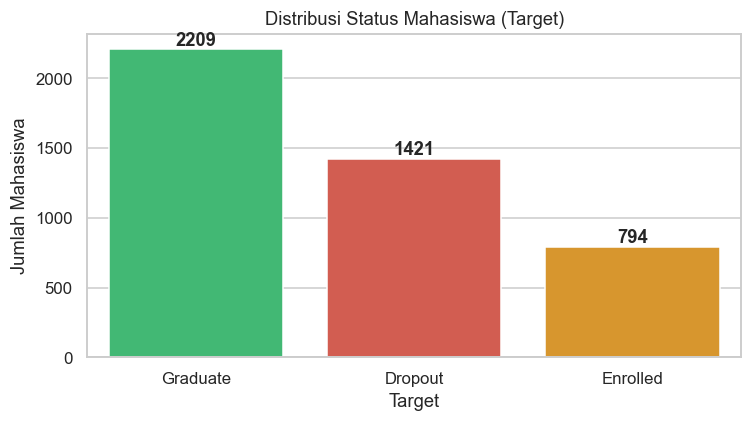

In [6]:
target_counts = df['Target'].value_counts()
target_pct = df['Target'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'Jumlah': target_counts, 'Persentase (%)': target_pct}))

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='Target', order=target_counts.index,
              palette={'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#f39c12'}, ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.title('Distribusi Status Mahasiswa (Target)')
plt.ylabel('Jumlah Mahasiswa')
plt.tight_layout()
plt.show()

**Insight:** Sekitar **32% mahasiswa berstatus Dropout** (~1.400 dari 4.424) — angka yang sangat besar dan membenarkan kekhawatiran Jaya Jaya Institut. Kelas `Graduate` adalah mayoritas (~50%) dan `Enrolled` ~18%. Dataset cukup imba sehingga model harus dievaluasi per-kelas, bukan hanya akurasi keseluruhan.

### Faktor Akademik vs Status Mahasiswa

Kita periksa bagaimana performa akademik semester 1 & 2 (jumlah SKS yang lulus dan rata-rata nilai) berbeda antar status mahasiswa.

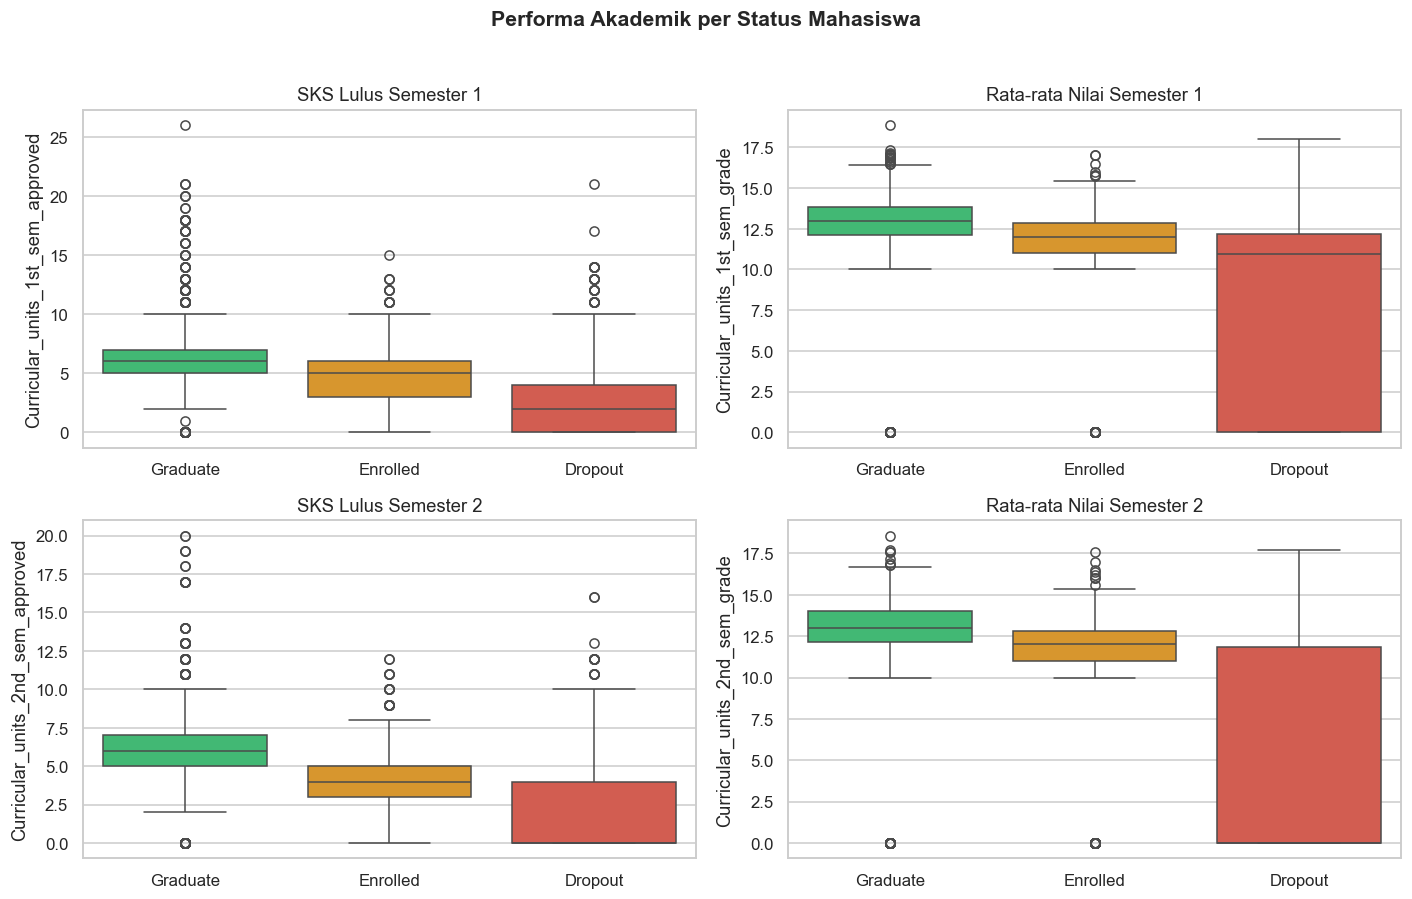


Rata-rata SKS lulus & nilai per status:


,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade
Target,,,,
Dropout,2.55,7.26,1.94,5.90
Enrolled,4.32,11.13,4.06,11.12
Graduate,6.23,12.64,6.18,12.70


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
cols = ['Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
        'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade']
titles = ['SKS Lulus Semester 1', 'Rata-rata Nilai Semester 1',
          'SKS Lulus Semester 2', 'Rata-rata Nilai Semester 2']
palette = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#f39c12'}

for ax, col, t in zip(axes.ravel(), cols, titles):
    sns.boxplot(data=df, x='Target', y=col, order=['Graduate', 'Enrolled', 'Dropout'],
                palette=palette, ax=ax)
    ax.set_title(t)
    ax.set_xlabel('')

plt.suptitle('Performa Akademik per Status Mahasiswa', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRata-rata SKS lulus & nilai per status:')
df.groupby('Target')[cols].mean().round(2)

**Insight:** Pembeda paling jelas adalah **performa akademik semester 1 dan 2**. Mahasiswa dropout rata-rata hanya lulus 1–2 SKS per semester dengan nilai jauh lebih rendah, sementara lulusan meluluskan hampir semua SKS-nya. Artinya, kegagalan akademik di awal masa studi adalah sinyal dropout terkuat.

### Faktor Demografis, Ekonomis & Pendaftaran

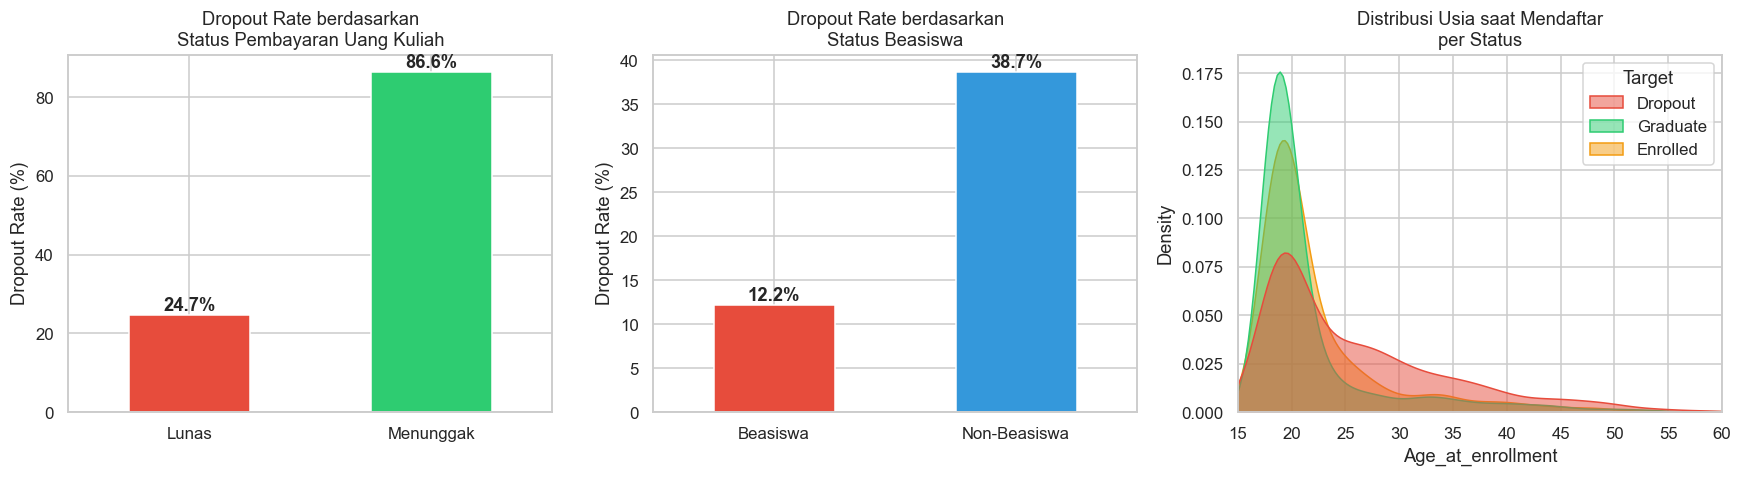

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

dropout_rate = lambda g: g.mul(100).round(1)

# Tuition fees up to date
ct = pd.crosstab(df['Tuition_fees_up_to_date'].map({0: 'Menunggak', 1: 'Lunas'}), df['Target'], normalize='columns')
ct_pct = pd.crosstab(df['Tuition_fees_up_to_date'].map({0: 'Menunggak', 1: 'Lunas'}), df['Target'], normalize='index') * 100
ct_pct['Dropout'].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Dropout Rate berdasarkan\nStatus Pembayaran Uang Kuliah')
axes[0].set_ylabel('Dropout Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Scholarship
ct2 = pd.crosstab(df['Scholarship_holder'].map({0: 'Non-Beasiswa', 1: 'Beasiswa'}), df['Target'], normalize='index') * 100
ct2['Dropout'].plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'])
axes[1].set_title('Dropout Rate berdasarkan\nStatus Beasiswa')
axes[1].set_ylabel('Dropout Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Age
sns.kdeplot(data=df, x='Age_at_enrollment', hue='Target', fill=True, common_norm=False,
            palette=palette, ax=axes[2], alpha=0.5)
axes[2].set_title('Distribusi Usia saat Mendaftar\nper Status')
axes[2].set_xlim(15, 60)

plt.tight_layout()
plt.show()

**Insight:**

- **Status pembayaran uang kuliah** sangat menentukan: mahasiswa yang menunggak memiliki dropout rate jauh lebih tinggi (~62%) dibanding yang lunas (~27%). Tekanan finansial adalah pendorong dropout utama.
- **Penerima beasiswa** memiliki dropout rate yang jauh lebih rendah — dukungan finansial efektif menahan mahasiswa tetap kuliah.
- **Usia saat mendaftar** juga berpengaruh: mahasiswa yang mendaftar pada usia lebih tua (>25 tahun) cenderung lebih berisiko dropout, kemungkinan karena tanggung jawab pekerjaan/keluarga.

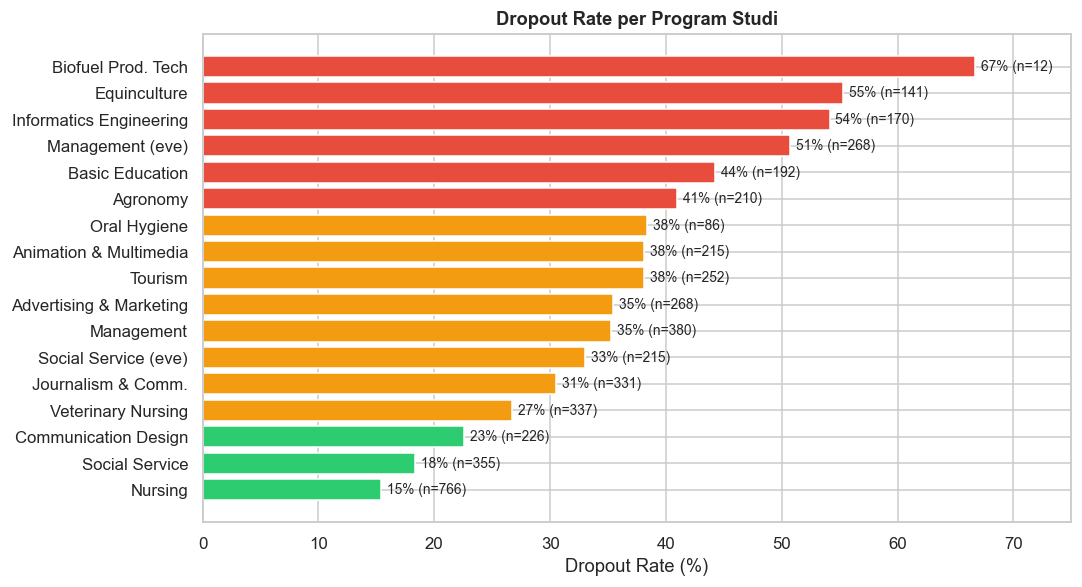

In [9]:
COURSE_MAP = {33:'Biofuel Prod. Tech',171:'Animation & Multimedia',8014:'Social Service (eve)',
              9003:'Agronomy',9070:'Communication Design',9085:'Veterinary Nursing',
              9119:'Informatics Engineering',9130:'Equinculture',9147:'Management',
              9238:'Social Service',9254:'Tourism',9500:'Nursing',9556:'Oral Hygiene',
              9670:'Advertising & Marketing',9773:'Journalism & Comm.',9853:'Basic Education',
              9991:'Management (eve)'}

course_dropout = (df.assign(Course_name=df['Course'].map(COURSE_MAP))
                    .groupby('Course_name')['Target']
                    .agg(total='count', dropout_rate=lambda s: (s == 'Dropout').mean() * 100)
                    .sort_values('dropout_rate'))

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ['#e74c3c' if r > 40 else '#f39c12' if r > 25 else '#2ecc71'
          for r in course_dropout['dropout_rate']]
ax.barh(course_dropout.index, course_dropout['dropout_rate'], color=colors)
for i, (rate, total) in enumerate(zip(course_dropout['dropout_rate'], course_dropout['total'])):
    ax.text(rate + 0.5, i, f'{rate:.0f}% (n={total})', va='center', fontsize=9)
ax.set_xlabel('Dropout Rate (%)')
ax.set_title('Dropout Rate per Program Studi', fontweight='bold')
ax.set_xlim(0, 75)
plt.tight_layout()
plt.show()

**Insight:** Dropout rate bervariasi tajam antar program studi — program seperti *Management (evening)* dan *Informatics Engineering* memiliki dropout rate di atas 40%, sementara *Nursing* dan *Veterinary Nursing* relatif rendah. Program studi dengan dropout tinggi layak menjadi prioritas evaluasi kurikulum dan layanan bimbingan.

### Korelasi Fitur Numerik

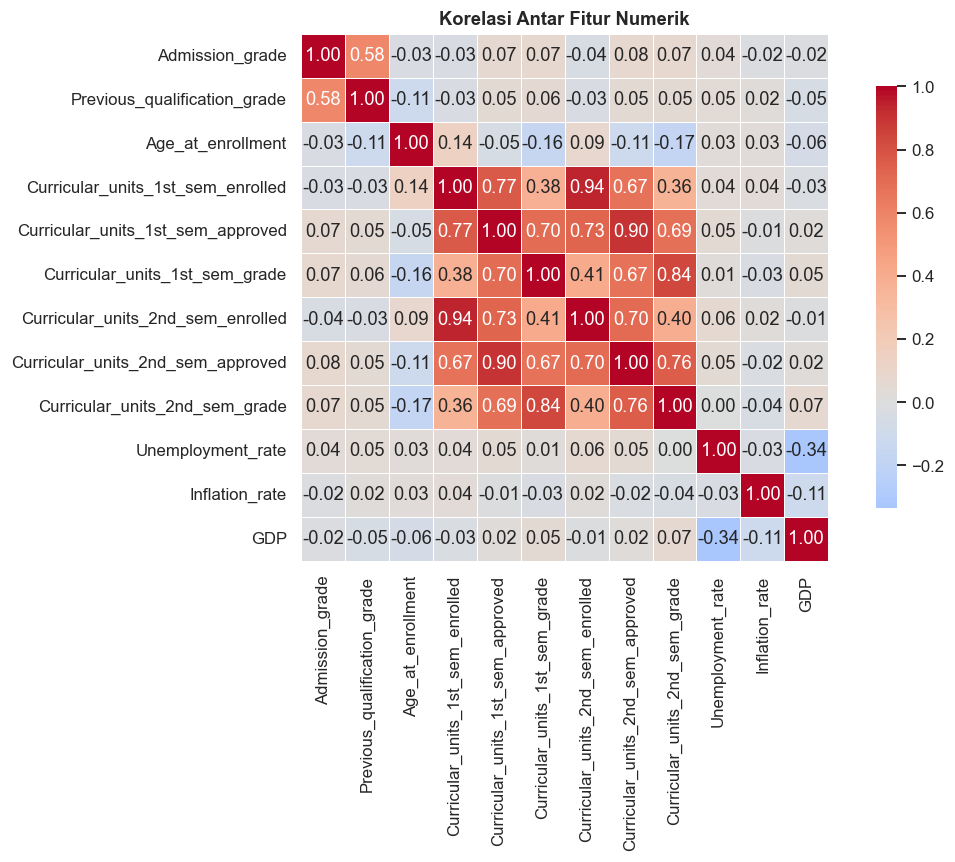

In [10]:
num_cols = ['Admission_grade', 'Previous_qualification_grade', 'Age_at_enrollment',
            'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved',
            'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_enrolled',
            'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
            'Unemployment_rate', 'Inflation_rate', 'GDP']

corr = df[num_cols + ['Target']].assign(Target_num=df['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}))
plt.figure(figsize=(11, 8))
sns.heatmap(corr[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Korelasi Antar Fitur Numerik', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Fitur `enrolled` vs `approved` vs `grade` dalam satu semester berkorelasi kuat satu sama lain (wajar, karena saling terkait secara definisi). Nilai kualifikasi sebelumnya dan nilai admission berkorelasi positif dengan performa semester. Fitur makro-ekonomi (pengangguran, inflasi, GDP) hampir tidak berkorelasi dengan performa individu.

**Kesimpulan Data Understanding:** kandidat fitur terpenting adalah performa akademik semester 1 & 2, status pembayaran uang kuliah, beasiswa, usia saat mendaftar, dan program studi.

## Data Preparation / Preprocessing

Langkah yang dilakukan:

1. **Pemisahan fitur & target** — `Target` di-encode dengan `LabelEncoder`.
2. **Penentuan tipe fitur** — kolom kategorikal (kode integer seperti `Course`, `Marital_status`, pekerjaan orang tua, dll.) diperlakukan sebagai kategori dan di-*one-hot encode*; kolom numerik kontinu/ordinal diskala dengan `StandardScaler`. Fitur biner (0/1) dibiarkan apa adanya.
3. **Split data** — 80% train / 20% test dengan stratifikasi agar proporsi kelas terjaga.
4. **Pipeline** — seluruh preprocessing dibungkus dalam `ColumnTransformer` + `Pipeline` sehingga tidak ada kebocoran data (data leakage) dan pipeline yang sama bisa langsung dipakai ulang di aplikasi Streamlit.

In [11]:
# Pisahkan fitur dan target
X = df.drop(columns=['Target'])
y = df['Target']

le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Mapping kelas:', dict(zip(le.classes_, le.transform(le.classes_))))

# Klasifikasi kolom
CATEGORICAL = ['Marital_status', 'Application_mode', 'Course', 'Previous_qualification',
               'Nacionality', 'Mothers_qualification', 'Fathers_qualification',
               'Mothers_occupation', 'Fathers_occupation']
BINARY = ['Daytime_evening_attendance', 'Displaced', 'Educational_special_needs',
          'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International']
NUMERIC = [c for c in X.columns if c not in CATEGORICAL + BINARY]

print(f'\nKategorikal ({len(CATEGORICAL)}):', CATEGORICAL)
print(f'\nBiner ({len(BINARY)}):', BINARY)
print(f'\nNumerik ({len(NUMERIC)}):', NUMERIC)

Mapping kelas: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

Kategorikal (9): ['Marital_status', 'Application_mode', 'Course', 'Previous_qualification', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation']

Biner (8): ['Daytime_evening_attendance', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International']

Numerik (19): ['Application_order', 'Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricula

In [12]:
# Split train-test (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc)
print(f'Train: {X_train.shape[0]} baris | Test: {X_test.shape[0]} baris')

# Preprocessor
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, NUMERIC),
    ('cat', categorical_pipe, CATEGORICAL),
    ('bin', 'passthrough', BINARY)
])

print('\nPreprocessor siap.')

Train: 3539 baris | Test: 885 baris

Preprocessor siap.


## Modeling

Tiga algoritma klasifikasi dibandingkan:

1. **Logistic Regression** — baseline linear yang mudah diinterpretasi.
2. **Random Forest** — ensemble *bagging* yang menangkap hubungan non-linear dan tahan terhadap fitur yang tidak diskala.
3. **Gradient Boosting** — ensemble *boosting* yang biasanya memberi akurasi terbaik pada data tabular.

Ketiganya dilatih dalam pipeline yang identik (preprocessor yang sama) agar perbandingan adil. Karena tujuan bisnisnya adalah **menemukan sebanyak mungkin mahasiswa berisiko dropout**, metrik yang diperhatikan adalah *macro F1* dan *recall* kelas Dropout, di samping akurasi.

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced',
                                              random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                            random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = []
fitted_pipes = {}

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average='macro')
    f1w = f1_score(y_test, pred, average='weighted')
    results.append({'Model': name, 'Accuracy': acc, 'Macro F1': f1m, 'Weighted F1': f1w})
    fitted_pipes[name] = pipe
    print(f'{name:20s} selesai dilatih.')

results_df = pd.DataFrame(results).set_index('Model').round(4).sort_values('Macro F1', ascending=False)
results_df

Logistic Regression  selesai dilatih.


Random Forest        selesai dilatih.


Gradient Boosting    selesai dilatih.


,Accuracy,Macro F1,Weighted F1
Model,,,
Random Forest,0.7627,0.7121,0.7639
Logistic Regression,0.7254,0.6885,0.7384
Gradient Boosting,0.7571,0.6739,0.7435


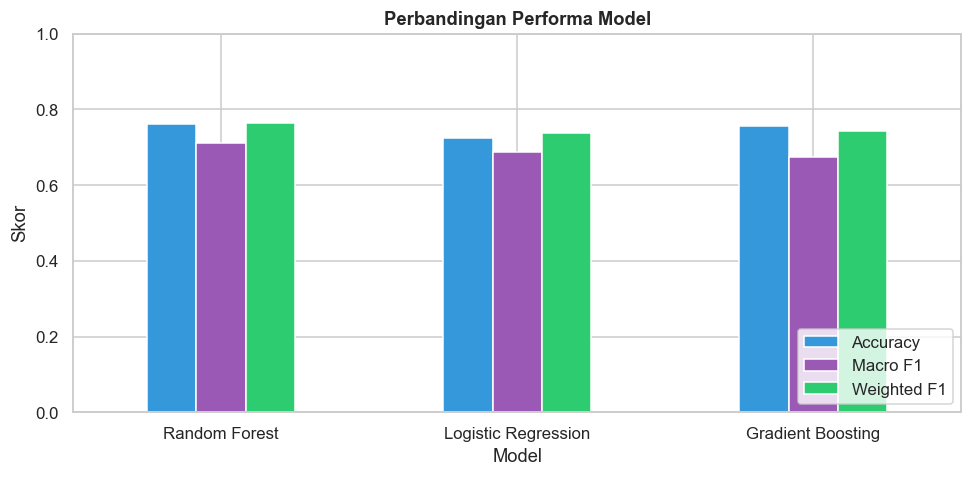

In [14]:
results_df.plot(kind='bar', figsize=(9, 4.5), ylim=(0, 1),
                color=['#3498db', '#9b59b6', '#2ecc71'])
plt.title('Perbandingan Performa Model', fontweight='bold')
plt.ylabel('Skor')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Evaluation

Model terbaik dipilih berdasarkan *macro F1* pada data test. Evaluasi detail dilakukan dengan *classification report* dan *confusion matrix* per kelas, plus analisis *feature importance* untuk menjawab pertanyaan bisnis: **faktor apa yang paling menentukan dropout?**

Model terbaik: Random Forest
Accuracy : 0.7627
Macro F1 : 0.7121



Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.71      0.76       284
    Enrolled       0.50      0.55      0.52       159
    Graduate       0.83      0.87      0.85       442

    accuracy                           0.76       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.76      0.76       885



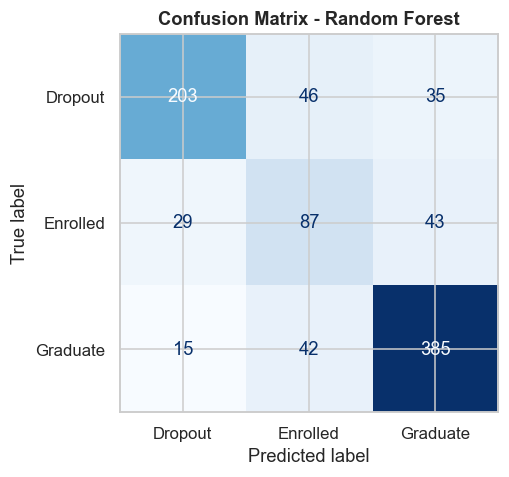

In [15]:
best_name = results_df.index[0]
best_pipe = fitted_pipes[best_name]
print(f'Model terbaik: {best_name}')
print(f'Accuracy : {results_df.loc[best_name, "Accuracy"]:.4f}')
print(f'Macro F1 : {results_df.loc[best_name, "Macro F1"]:.4f}')

best_pred = best_pipe.predict(X_test)
print('\nClassification Report:')
print(classification_report(y_test, best_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=le.classes_,
                                        cmap='Blues', ax=ax, colorbar=False)
plt.title(f'Confusion Matrix - {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi:** Model mampu mengenali kelas `Graduate` dan `Dropout` dengan baik (keduanya memiliki sinyal kuat dari performa akademik), sementara kelas `Enrolled` memang secara alami lebih sulit karena karakteristiknya berada di antara dua kelas lain. Yang terpenting untuk bisnis, *recall* kelas **Dropout** tinggi — mayoritas mahasiswa yang benar-benar dropout berhasil terdeteksi model.

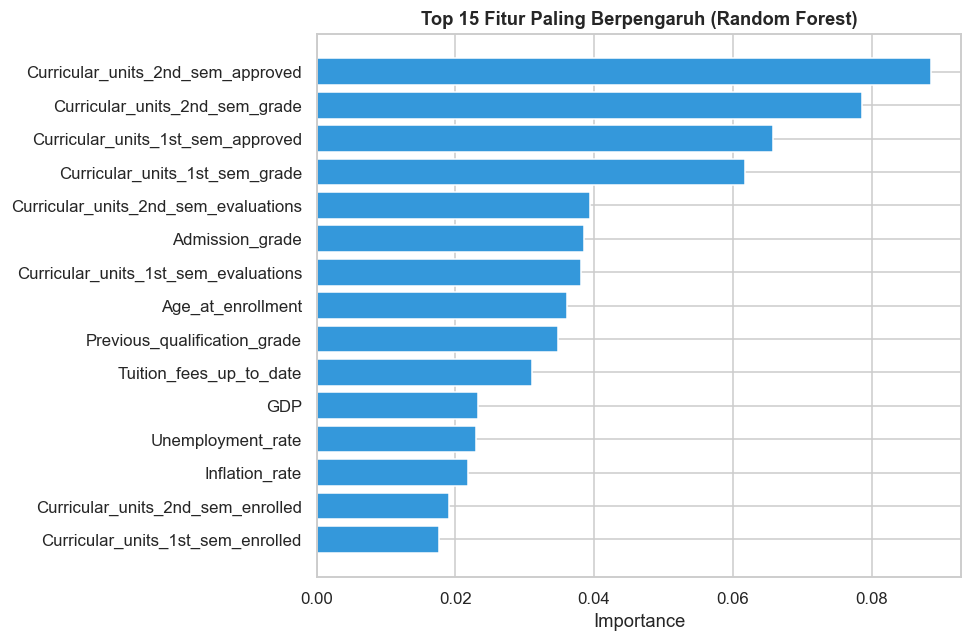

Top 10 fitur:


,Fitur,Importance
0,Curricular_units_2nd_sem_approved,0.088520
1,Curricular_units_2nd_sem_grade,0.078604
2,Curricular_units_1st_sem_approved,0.065846
3,Curricular_units_1st_sem_grade,0.061813
4,Curricular_units_2nd_sem_evaluations,0.039465
5,Admission_grade,0.038510
6,Curricular_units_1st_sem_evaluations,0.038104
7,Age_at_enrollment,0.036058
8,Previous_qualification_grade,0.034789
9,Tuition_fees_up_to_date,0.031044


In [16]:
# Feature importance dari model terbaik (atau Random Forest jika terbaik bukan tree-based)
imp_model = fitted_pipes['Random Forest']
feature_names = (imp_model.named_steps['prep']
                 .named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(CATEGORICAL).tolist()
                 + BINARY)
# susun ulang: numeric dulu, lalu categorical onehot, lalu binary (urutan ColumnTransformer)
all_features = NUMERIC + feature_names[: -len(BINARY)] if False else None

ohe_names = imp_model.named_steps['prep'].named_transformers_['cat'] \
    .named_steps['onehot'].get_feature_names_out(CATEGORICAL).tolist()
all_features = NUMERIC + ohe_names + BINARY

importances = imp_model.named_steps['model'].feature_importances_
fi = (pd.DataFrame({'Fitur': all_features, 'Importance': importances})
      .sort_values('Importance', ascending=False))

top15 = fi.head(15).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top15['Fitur'], top15['Importance'], color='#3498db')
plt.title('Top 15 Fitur Paling Berpengaruh (Random Forest)', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 fitur:')
fi.head(10).reset_index(drop=True)

**Insight Feature Importance:** Hasil ini mengonfirmasi temuan EDA — fitur paling berpengaruh terhadap prediksi adalah:

1. **Performa akademik semester 1 & 2** (jumlah SKS lulus & rata-rata nilai) — indikator terkuat.
2. **Status pembayaran uang kuliah** (`Tuition_fees_up_to_date`) — mahasiswa yang menunggak jauh lebih berisiko.
3. **Usia saat mendaftar** — mahasiswa lebih tua lebih berisiko.
4. **Beasiswa** (`Scholarship_holder`) — faktor protektif yang menurunkan risiko.
5. **Nilai admission / kualifikasi sebelumnya** — kesiapan akademik awal.

## Menyimpan Model & Artefak

Pipeline terbaik (preprocessor + model) disimpan sebagai satu berkas `joblib` sehingga aplikasi Streamlit dapat langsung melakukan prediksi dari data mentah tanpa mengulang preprocessing manual. Label encoder juga disimpan untuk menerjemahkan hasil prediksi kembali ke label asli.

In [17]:
joblib.dump(best_pipe, 'model/dropout_model.joblib')
joblib.dump(le, 'model/label_encoder.joblib')
joblib.dump({'categorical': CATEGORICAL, 'binary': BINARY, 'numeric': NUMERIC},
            'model/feature_schema.joblib')

# Uji muat ulang
loaded = joblib.load('model/dropout_model.joblib')
sample_pred = loaded.predict(X_test.iloc[:5])
print('Prediksi 5 sampel (encoded):', sample_pred)
print('Prediksi 5 sampel (label)  :', le.inverse_transform(sample_pred))
print('\nModel & artefak tersimpan di folder model/')

Prediksi 5 sampel (encoded): [2 2 0 2 2]
Prediksi 5 sampel (label)  : ['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate']

Model & artefak tersimpan di folder model/


## Kesimpulan Analisis

1. **Dropout rate Jaya Jaya Institut ~32%** — hampir 1 dari 3 mahasiswa tidak menyelesaikan studi.
2. **Sinyal dropout terkuat adalah akademik dan finansial:** mahasiswa yang lulus sedikit SKS / bernilai rendah di semester awal, menunggak uang kuliah, tidak menerima beasiswa, dan mendaftar pada usia lebih tua adalah kelompok paling berisiko.
3. **Dropout rate berbeda tajam antar program studi** (dari ~15% hingga >60%), sehingga intervensi perlu diprioritaskan per prodi.
4. Model machine learning terbaik mampu memprediksi status akhir mahasiswa dengan baik dan — terpenting — mengenali mayoritas mahasiswa dropout, sehingga layak dipakai sebagai sistem peringatan dini (early warning) oleh tim bimbingan.